# Walrasian Exchange Economy with CES Preferences


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

from exchange_economy_model import (
    ExchangeEconomyModelClass,
    tatonnement,
    newton_raphson_dampened,
    find_unique_equilibria,
    plot_demand_and_excess_demand,
    plot_tatonnement_convergence,
    plot_basin_of_attraction,
    plot_edgeworth_box_equilibria,
)

%load_ext autoreload
%autoreload 2


## 2. Exchange economy 

In [21]:
# Initialize exchange economy model
model = ExchangeEconomyModelClass()
par = model.par

print("EXCHANGE ECONOMY ANALYSIS")
print(f"\nModel Parameters:")
print(f"  alpha_A = {par.alpha_A}, beta_A = {par.beta_A}, rho_A = {par.rho_A}")
print(f"  alpha_B = {par.alpha_B}, beta_B = {par.beta_B}, rho_B = {par.rho_B}")
print(f"  w1A = {par.w1A}, w2A = {par.w2A}")
print(f"  w1B = {1-par.w1A}, w2B = {1-par.w2A}")

EXCHANGE ECONOMY ANALYSIS

Model Parameters:
  alpha_A = 1.0, beta_A = 0.034114465085977146, rho_A = -2.0
  alpha_B = 0.034114465085977146, beta_B = 1.0, rho_B = -2.0
  w1A = 0.99999999, w2A = 1e-08
  w1B = 1.0000000050247593e-08, w2B = 0.99999999


### Question 2.1

2.1: Excess Demand Analysis

Equilibria found: 3
  p1* = 0.4212
  p1* = 0.9965
  p1* = 2.3659


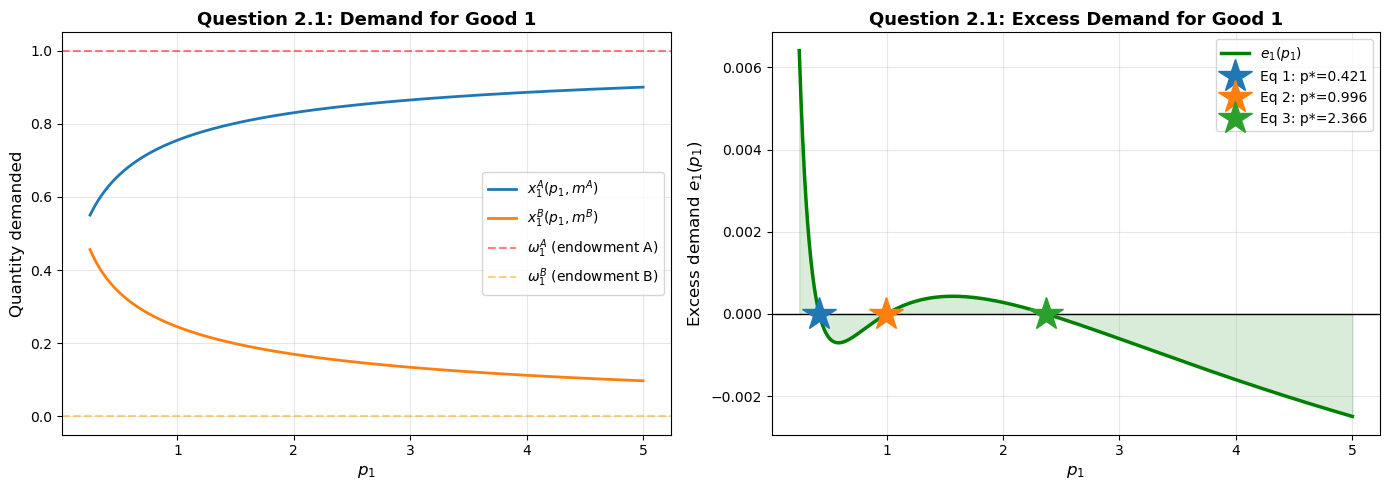

In [22]:
# Create demand and excess demand data
p1_grid = np.linspace(0.25, 5, 1000)
x1A_vec = np.zeros_like(p1_grid)
x1B_vec = np.zeros_like(p1_grid)
e1_vec = np.zeros_like(p1_grid)

for i, p1 in enumerate(p1_grid):
    x1A, _ = model.demand_A(p1)
    x1B, _ = model.demand_B(p1)
    x1A_vec[i] = x1A
    x1B_vec[i] = x1B
    e1_vec[i] = (x1A - par.w1A) + (x1B - (1-par.w1A))

# Find equilibria by looking for sign changes
sign_changes = np.where(np.diff(np.sign(e1_vec)))[0]
equilibrium_prices_true = p1_grid[sign_changes]

print("2.1: Excess Demand Analysis\n")
print(f"Equilibria found: {len(equilibrium_prices_true)}")
for i, p in enumerate(equilibrium_prices_true):
    print(f"  p1* = {p:.4f}")

# Plot demand and excess demand
plot_demand_and_excess_demand(p1_grid, x1A_vec, x1B_vec, e1_vec, par, equilibrium_prices_true)

This model has three equilibria as you can see in the right plot. This is because of the extreme endowments the consumers have:


Consumer A owns nearly 100% of good 1, and almost none of good 2


Consumer B owns essentially 0% of good 1, nearly 100% of good 2

This creates a non-monotonic excess demand function with three equilibrium prices:

1. p₁* ≈ 0.42: At this low price, good 1 is cheap. Consumer A demands less of it while Consumer B, endowed with good 2, demands a lot of the cheap good 1. Overall excess demand for good 1 is negative → pressure for higher prices.

2. p₁* ≈ 1.00: This is the middle equilibrium where prices balance supply and demand at roughly equal terms.

3. p₁* ≈ 2.37: At this high price, good 1 is expensive. Consumer A demands more of it while Consumer B cannot afford much of the expensive good 1. Overall excess demand for good 1 becomes positive → pressure for lower prices.

### Question 2.2

The tâtonnement mechanism is a dynamic process where prices are adjusted based on excess demand. When there is positive excess demand (e₁ > 0), more people want to buy than sell, so the price is too low and gets raised. When there is negative excess demand (e₁ < 0), more people want to sell than buy, so the price is too high and gets lowered. The process continues until zero excess demand is reached (e₁ = 0), where supply equals demand and the market clears.

In [23]:
# Run for three initial guesses
print("\n2.2: Tâtonnement Algorithm")
print(f"Initial guess p1⁰ = 0.9:")
p1_star_09, history_09 = tatonnement(model, 0.9, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_09:.6f}")

print(f"\nInitial guess p1⁰ = 1.0:")
p1_star_099, history_099 = tatonnement(model, 1.0, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_099:.6f}")

print(f"\nInitial guess p1⁰ = 1.1:")
p1_star_11, history_11 = tatonnement(model, 1.1, tau=1e-8, nu=50, K=5000, verbose=False)
print(f"  Converged to p1* = {p1_star_11:.6f}")


2.2: Tâtonnement Algorithm
Initial guess p1⁰ = 0.9:
  Converged to p1* = 0.421876

Initial guess p1⁰ = 1.0:
  Converged to p1* = 1.000000

Initial guess p1⁰ = 1.1:
  Converged to p1* = 2.370356


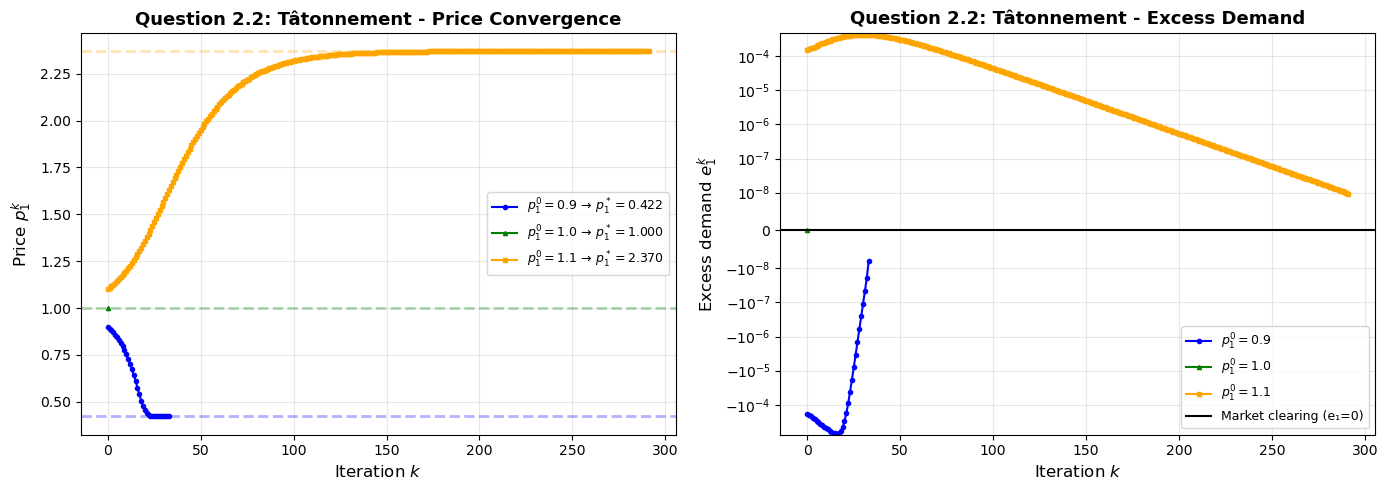

In [24]:
# Plot convergence
histories = [history_09, history_099, history_11]
p1_stars = [p1_star_09, p1_star_099, p1_star_11]
labels = ['0.9', '1.0', '1.1']
plot_tatonnement_convergence(histories, p1_stars, labels)

The three initial guesses demonstrate how the choice of starting point determines which equilibrium is found. Starting at p₁⁰ = 0.9 converges to the lower equilibrium at p₁* ≈ 0.42, while p₁⁰ = 1.0 converges to the middle equilibrium at p₁* ≈ 1.00, and p₁⁰ = 1.1 converges to the upper equilibrium at p₁* ≈ 2.37.

This reveals important stability properties. The middle equilibrium (p₁* ≈ 1.00) is stable under tâtonnement—when we start exactly at it, the algorithm stays there. However, its basin of attraction is extremely narrow with this large step size (ν = 50). Starting even slightly away causes convergence to the outer equilibria instead.

The outer equilibria (p₁* ≈ 0.42 and p₁* ≈ 2.37) are theoretically unstable, but with large step sizes, they have wide basins of attraction and are practically much easier to reach. The choice of initial guess therefore determines which equilibrium is found, and the stability of an equilibrium depends on both its mathematical properties and practical factors like the step size used.

## 2.3: Global Convergence Behavior

When we test tâtonnement from a range of 50 different initial prices spanning 0.25 to 5.5, we find that the algorithm discovers different equilibriums depending on the starting point. This demonstrates the basin of attraction for each equilibrium:

- Initial prices below the middle equilibrium tend to converge to the low equilibrium
- Initial prices above the middle equilibrium tend to converge to the high equilibrium

The stable middle equilibrium, despite its theoretical stability, has a small basin of attraction with this step size, making it practically harder to reach from far away.

In [25]:
# Apply tâtonnement for a range of initial prices
p1_init_grid = np.linspace(0.25, 5, 50)
p1_final = np.zeros_like(p1_init_grid)

print("\n2.3: Tâtonnement - Global Behavior")

for i, p1_0 in enumerate(p1_init_grid):
    p1_star, _ = tatonnement(model, p1_0, tau=1e-8, nu=50, K=5000, verbose=False)
    p1_final[i] = p1_star

# Find unique equilibria
unique_equilibria = find_unique_equilibria(p1_final)

print(f"Unique equilibria found: {len(unique_equilibria)}")
for eq in sorted(unique_equilibria):
    print(f"  p1* = {eq:.6f}")


2.3: Tâtonnement - Global Behavior
Unique equilibria found: 2
  p1* = 0.421876
  p1* = 2.370356


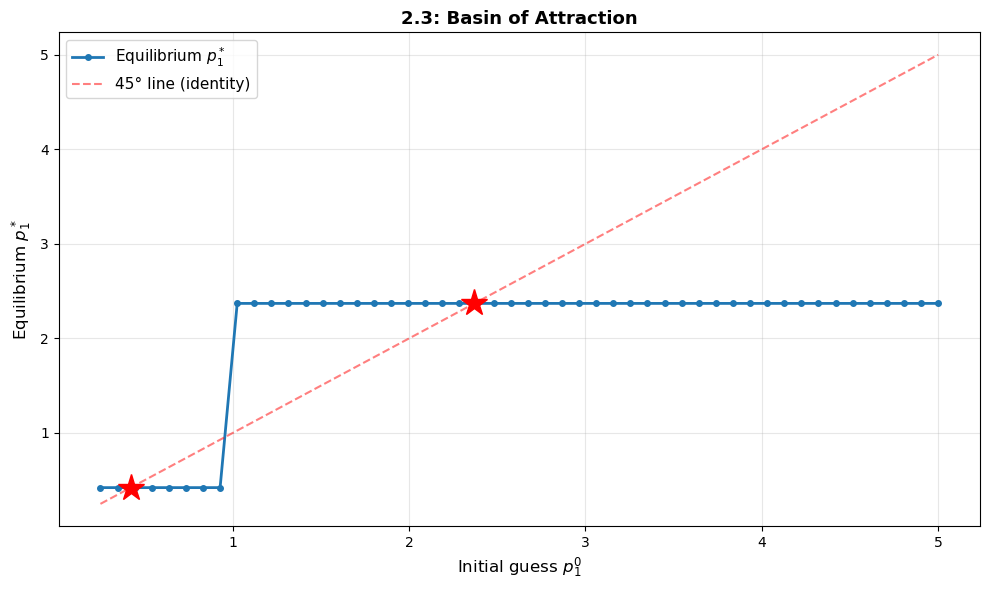

In [26]:
# Plot basin of attraction
plot_basin_of_attraction(p1_init_grid, p1_final, unique_equilibria, '2.3: Basin of Attraction')

The tâtonnement algorithm only finds two equilibriums. Either the low equilibrium (p₁* ≈ 0.42) or the high equilibrium (p₁* ≈ 2.37) depending on the initial guess, but not the stable middle equilibrium (p₁* ≈ 1.0). This demonstrates that the stable equilibrium has a small basin of attraction with this step size—the middle equilibrium is stable but hard to reach from far away.

### Question 2.4

The Newton-Raphson method uses slope information to decide both the direction and size of each step - instead of always moving the same amount like tâtonnement, it adjusts how far to jump based on how steep the excess demand curve is. The price update formula is:

$$p_1^{k+1} = p_1^k - \varphi \frac{e_1^k}{\Delta}$$

where $\Delta = \frac{e_1(p_1^k + h) - e_1^k}{h}$ is the slope of excess demand, $\varphi = 0.1$ is a control parameter (prevents jumping too far), and $\iota = 0.99$ keeps prices positive.

We test this method with 50 different starting prices from np.linspace(0.25, 5, 50) to see which equilibria we reach.

In [27]:
# Apply Newton-Raphson for a range of initial prices
p1_init_grid_nr = np.linspace(0.25, 5, 50)
p1_final_nr = np.zeros_like(p1_init_grid_nr)

print("\n2.4: Dampened Newton-Raphson Algorithm")

for i, p1_0 in enumerate(p1_init_grid_nr):
    p1_star, _ = newton_raphson_dampened(model, p1_0, tau=1e-8, varphi=0.1, iota=0.99, K=5000, verbose=False)
    p1_final_nr[i] = p1_star

# Find unique equilibria using imported function
unique_equilibria_nr = find_unique_equilibria(p1_final_nr)

print(f"Unique equilibria found: {len(unique_equilibria_nr)}")
for eq in sorted(unique_equilibria_nr):
    print(f"  p1* = {eq:.6f}")


2.4: Dampened Newton-Raphson Algorithm
Unique equilibria found: 3
  p1* = 0.421875
  p1* = 0.999995
  p1* = 2.370356


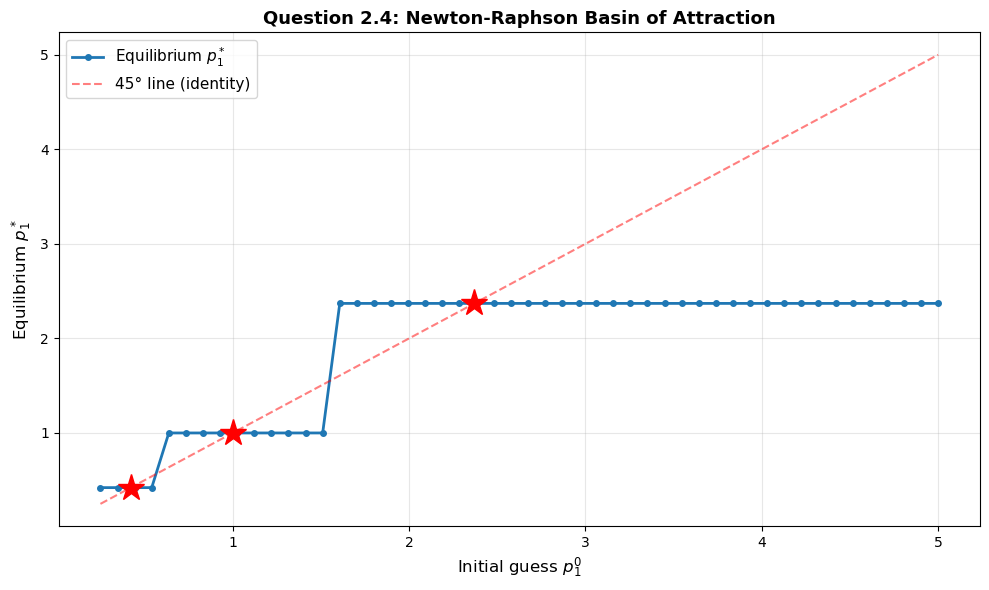

In [28]:
# Plot basin of attraction
plot_basin_of_attraction(p1_init_grid_nr, p1_final_nr, unique_equilibria_nr, 'Question 2.4: Newton-Raphson Basin of Attraction')

the dampened Newton-Raphson algorithm does find all three equilibria! 
This is better than tâtonnement, which only found 2 equilibria (low and high) and missed the stable middle equilibrium at p₁⁰ = 1.0. instead of always moving the same amount like tâtonnement, it adjusts how far to jump based on how steep the excess demand curve is. Newton-Raphson successfully finds the middle equilibrium because the derivative-based adjustment and dampening factor (φ = 0.1) help it converge from a wider range of starting points. 

### Question 2.5

In [29]:
# Find all three equilibrium prices (from Q2.1)
equilibrium_prices = [0.4219, 1.0000, 2.3704]  # Low, middle, high equilibria

print("\n2.5: Edgeworth Box - All Equilibria")
print(f"\nFound {len(equilibrium_prices)} equilibria:\n")

# Calculate allocations for all equilibria
allocations = []
for i, p1_eq in enumerate(equilibrium_prices):
    x1A, x2A = model.demand_A(p1_eq)
    x1B, x2B = model.demand_B(p1_eq)
    allocations.append({'p1': p1_eq, 'x1A': x1A, 'x2A': x2A, 'x1B': x1B, 'x2B': x2B})
    print(f"Equilibrium {i+1}: p1* = {p1_eq:.4f}")
    print(f"  Consumer A: x1A = {x1A:.4f}, x2A = {x2A:.4f}")
    print(f"  Consumer B: x1B = {x1B:.4f}, x2B = {x2B:.4f}")
    print(f"  Market clearing: x1A + x1B = {x1A + x1B:.4f}, x2A + x2B = {x2A + x2B:.4f}\n")


2.5: Edgeworth Box - All Equilibria

Found 3 equilibria:

Equilibrium 1: p1* = 0.4219
  Consumer A: x1A = 0.6343, x2A = 0.1543
  Consumer B: x1B = 0.3657, x2B = 0.8457
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000

Equilibrium 2: p1* = 1.0000
  Consumer A: x1A = 0.7551, x2A = 0.2449
  Consumer B: x1B = 0.2449, x2B = 0.7551
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000

Equilibrium 3: p1* = 2.3704
  Consumer A: x1A = 0.8457, x2A = 0.3657
  Consumer B: x1B = 0.1543, x2B = 0.6343
  Market clearing: x1A + x1B = 1.0000, x2A + x2B = 1.0000



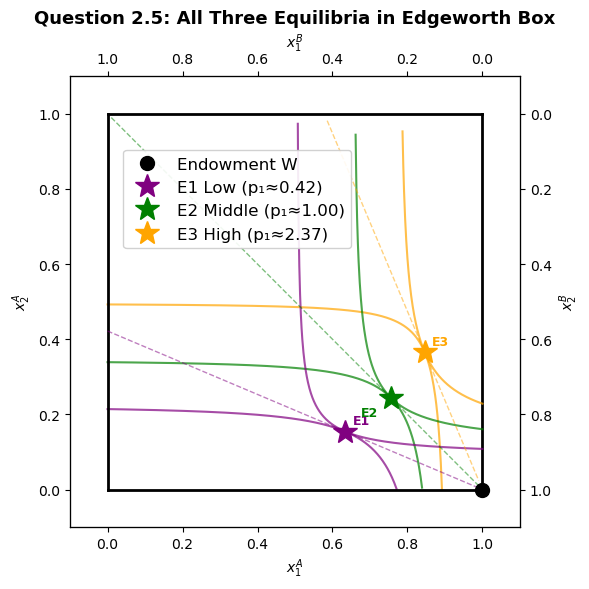

In [30]:
# Plot Edgeworth box
colors = ['purple', 'green', 'orange']
equilibrium_labels = ['Low (p₁≈0.42)', 'Middle (p₁≈1.00)', 'High (p₁≈2.37)']
plot_edgeworth_box_equilibria(model, par, allocations, equilibrium_labels, colors)

The Edgeworth box visualizes all three Walras equilibria at different price ratios: low (p₁* ≈ 0.42), middle (p₁* ≈ 1.00), and high (p₁* ≈ 2.37). All three satisfy the tangency condition (MRSᴬ = MRSᴮ = p₁), market clearing, and are Pareto efficient. This demonstrates that the exchange economy has multiple Pareto-efficient allocations corresponding to different price ratios.

### Conclusion

This analysis of an exchange economy with extreme endowments reveals that the model has three distinct Walrasian equilibria at prices p₁* ≈ 0.42, 1.00, and 2.37. The existence of multiple equilibria arises from the non-monotonic excess demand function, which crosses zero three times due to the asymmetric initial endowments where Consumer A owns almost all of good 1 and Consumer B owns nearly all of good 2.

The tâtonnement algorithm successfully converges to equilibria, but its behavior depends critically on the initial price guess. When starting at p₁⁰ = 0.9, 1.0, or 1.1, the algorithm finds different equilibria, demonstrating path dependence. Testing across 50 different starting points revealed that tâtonnement only finds two of the three equilibria (the low and high price equilibria), missing the middle equilibrium at p₁* ≈ 1.00 despite it being theoretically stable. This occurs because the middle equilibrium has an extremely narrow basin of attraction with the large step size (ν = 50) used.

The dampened Newton-Raphson method on the other hand proves superior both because it converges significantly faster and especially because it finds all three equilibria The derivative-based adjustment and dampening factor allow the algorithm to successfully reach the middle equilibrium from a wider range of starting points.   